<a href="https://colab.research.google.com/github/SFMoonLess/First_Repo/blob/main/%D0%A6%D0%A2%D0%9B%D0%A03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Топ-5 лет по выработке:
      Год  Выработка млрд кВт•ч
32  2022              223371.0
31  2021              222436.0
30  2020              215746.0
29  2019              208784.0
28  2018              204275.0

Годы с КИУМ > 80%:
      Год  КИУМ
26  2016  83.1
27  2017  83.3
30  2020  80.3
31  2021  82.4
32  2022  80.4
33  2023  81.5

Фрагмент (последние 5 лет):
      Год  Выработка млрд кВт•ч Доля выработки
31  2021              222436.0         19,7 %
32  2022              223371.0            NaN
33  2023                2174.0            NaN
34  2024                 216.0         17,9 %
35  2025               21835.0        18,44 %

Статистика по периодам:
                    mean       max        sum
Период                                      
2000-2009    615.842105    1633.0    11701.0
2010-н.в.  82037.125000  223371.0  1312594.0


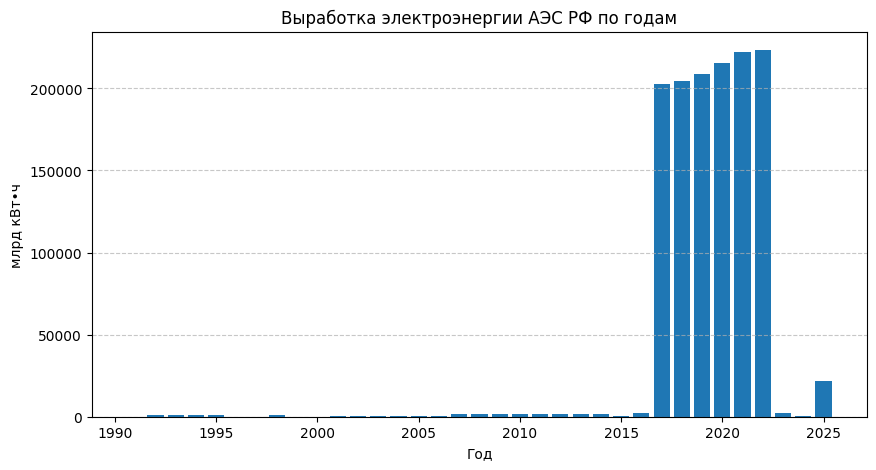

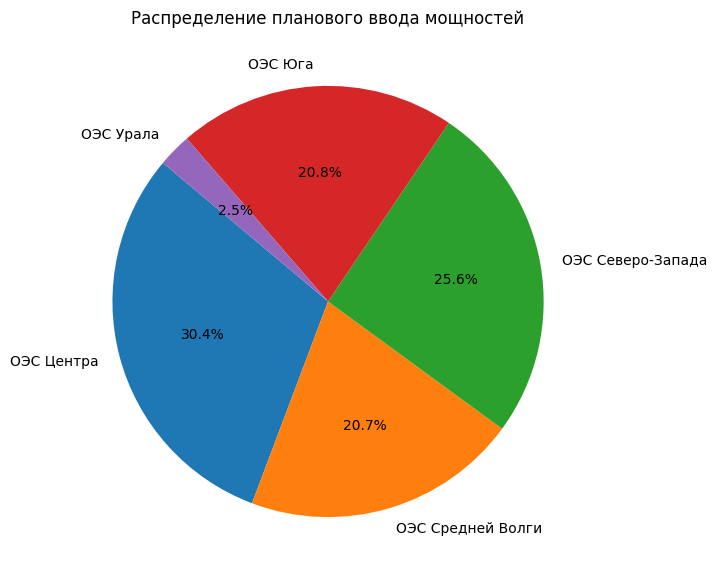

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import StringIO
from urllib.parse import quote
from bokeh.plotting import figure, show, output_notebook

# Включаем интерактивные графики
output_notebook()
topic = "Ядерная_энергетика_России"
encoded_url = "https://ru.wikipedia.org/wiki/" + quote(topic)
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(encoded_url, headers=headers)
response.raise_for_status()
html = StringIO(response.text)
tables = pd.read_html(html)

# Поиск нужной таблицы
df = None
for table in tables:
    joined_cols = " ".join([str(c) for c in table.columns.values])
    if "Год" in joined_cols and "Выработка" in joined_cols:
        df = table.copy()
        break

if df is None:
    raise Exception("Таблица с данными о выработке не найдена")

# 2. Обработка заголовков
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        " ".join([str(x) for x in col if 'nan' not in str(x)]).strip()
        for col in df.columns.values
    ]

df.columns = [str(col).split('[')[0].strip() for col in df.columns]
# Поиск нужных столбцов
year_col = 'Год'

gen_col = None
for c in df.columns:
    if 'Выработка' in c and 'млрд' in c:
        gen_col = c
        break

if gen_col is None:
    raise Exception("Столбец 'Выработка' не найден")

kium_col = None
for c in df.columns:
    if 'КИУМ' in c:
        kium_col = c
        break

if kium_col is None:
    raise Exception("Столбец 'КИУМ' не найден")

# Функция очистки чисел
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(r'\[.*?\]', '', regex=True)
        .str.replace('\xa0', '', regex=False)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
        .str.extract(r'(\d+\.?\d*)')[0],
        errors='coerce'
    )

# Очистка данных
df[year_col] = clean_numeric(df[year_col])
df[gen_col] = clean_numeric(df[gen_col])
df[kium_col] = clean_numeric(df[kium_col].astype(str).str.replace('%', ''))

# Удаление пустых строк
df = df.dropna(subset=[year_col, gen_col])
df[year_col] = df[year_col].astype(int)


# Сортировка
df_sorted = df.sort_values(by=gen_col, ascending=False)
print("Топ-5 лет по выработке:\n", df_sorted[[year_col, gen_col]].head())

# Новый столбец
df['Среднесут_выработка'] = df[gen_col] / 365

# Фильтр
df_high_kium = df[df[kium_col] > 80]
print(f"\nГоды с КИУМ > 80%:\n", df_high_kium[[year_col, kium_col]])

# iloc
df_fragment = df.iloc[-5:, :3]
print("\nФрагмент (последние 5 лет):\n", df_fragment)

# Группировка
df['Период'] = np.where(df[year_col] < 2010, '2000-2009', '2010-н.в.')
stats = df.groupby('Период')[gen_col].agg(['mean', 'max', 'sum'])
print("\nСтатистика по периодам:\n", stats)

# Е. Гистограмма
plt.figure(figsize=(10, 5))
plt.bar(df[year_col], df[gen_col])
plt.title('Выработка электроэнергии АЭС РФ по годам')
plt.xlabel('Год')
plt.ylabel('млрд кВт•ч')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Ж. Круговая диаграмма
regions = ['ОЭС Центра', 'ОЭС Средней Волги', 'ОЭС Северо-Запада', 'ОЭС Юга', 'ОЭС Урала']
shares = [40.96, 27.9, 34.5, 28.1, 3.4]

plt.figure(figsize=(7, 7))
plt.pie(shares, labels=regions, autopct='%1.1f%%', startangle=140)
plt.title('Распределение планового ввода мощностей')
plt.show()

# З. Bokeh
p = figure(title="Динамика выработки электроэнергии АЭС РФ",
           x_axis_label='Год',
           y_axis_label='млрд кВт•ч',
           width=800,
           height=400)

p.line(df[year_col], df[gen_col], line_width=3)
p.circle(df[year_col], df[gen_col], size=8)

show(p)